In [1]:
import matplotlib as mpl

def plot_style_apply(template="usenix", span=False, usetex=False):
    """
    template : "acm" | "usenix" | "cmu" | "tahoma"
    span     : True = full text width, False = single column
    """
    cfg = {
        # ACM: Main text is Libertine (Serif). Plot best-practice is Biolinum (Sans-serif).
        "acm":    {"col": 3.348, "full": 7.026, "font": 9,  "family": "sans-serif", "fonts": ["Linux Biolinum O", "Linux Biolinum"]},
        
        # USENIX: Main text is Times (Serif). Plot best-practice is Helvetica/Arial (Sans-serif).
        "usenix": {"col": 3.346, "full": 6.951, "font": 10, "family": "sans-serif", "fonts": ["Helvetica", "Arial"]},
        
        "cmu":    {"col": 3.346, "full": 6.951, "font": 10, "family": "sans-serif", "fonts": ["CMU Sans Serif"]},
        "tahoma": {"col": 3.346, "full": 6.951, "font": 10, "family": "sans-serif", "fonts": ["Tahoma"]},
    }[template]

    width = cfg["full"] if span else cfg["col"]
    fs    = cfg["font"]
    family = cfg["family"]

    updates = {
        "font.size":          fs,
        "axes.titlesize":     fs,
        "axes.labelsize":     fs,
        "xtick.labelsize":    fs - 1,
        "ytick.labelsize":    fs - 1,
        "legend.fontsize":    fs - 1,
        "figure.figsize":     (width, width * 0.65),
        "figure.dpi":         300,
        "savefig.dpi":        300,
        "pdf.fonttype":       42,
        "ps.fonttype":        42,
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "font.family":        family,
        f"font.{family}":     cfg["fonts"], 
    }
    
    if usetex:
        preambles = {
            # Loads Libertine/Biolinum, then forces default family to sfdefault (Biolinum)
            "acm":    r"\usepackage[T1]{fontenc} \usepackage{libertine} \renewcommand{\familydefault}{\sfdefault}",
            
            # Loads Times for math, Helvetica for text, then forces default family to sfdefault (Helvetica)
            "usenix": r"\usepackage{mathptmx} \usepackage[scaled=0.92]{helvet} \renewcommand{\familydefault}{\sfdefault}",
            
            "cmu":    r"\renewcommand{\familydefault}{\sfdefault}", 
            "tahoma": r"\renewcommand{\familydefault}{\sfdefault}", 
        }
        updates["text.usetex"] = True
        updates["text.latex.preamble"] = preambles[template]

    mpl.rcParams.update(updates)
    return width

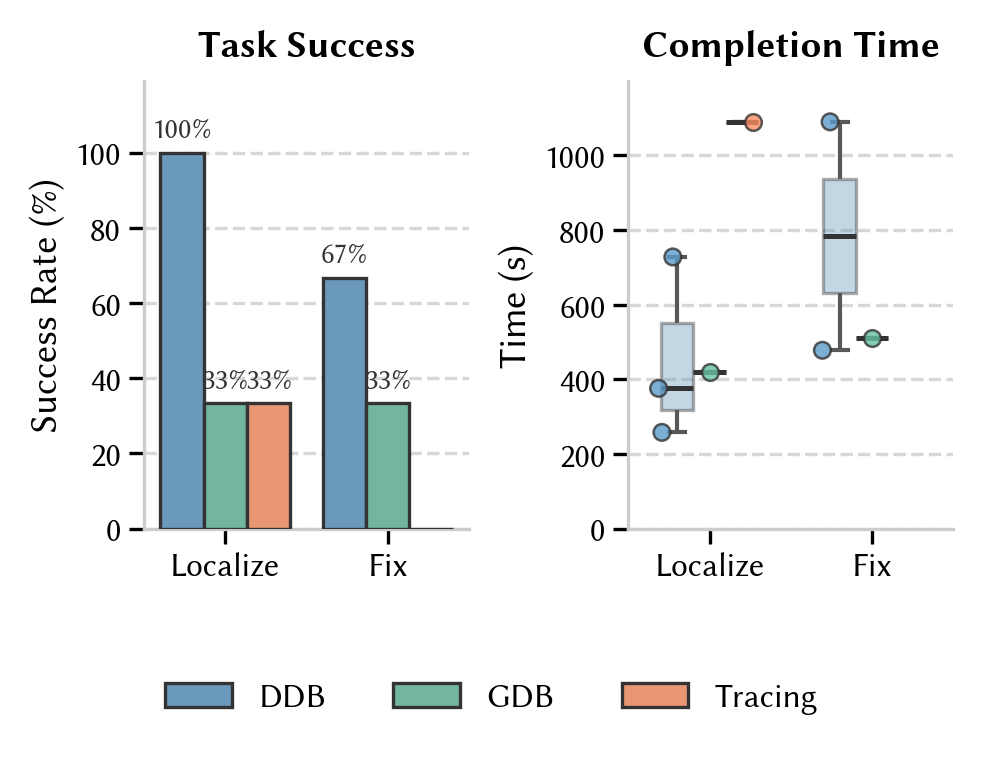

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hardcoded ACM width in inches for testing
width = plot_style_apply(template="acm", span=False, usetex=False)

# --- 1. STRICTLY YOUR REAL DATA ONLY ---
# Format: [User_ID, "System", Time-to-Localize, Time-to-Fix]
raw_data = [
    # --- User 1 ---
    [1, "DDB",     258,    478],
    [1, "Tracing", None,   None],
    [1, "GDB",     420,    510],

    # --- User 2 ---
    [2, "GDB",     None,   None],
    [2, "DDB",     376,    1090],
    [2, "Tracing", 1090,   None],

    # --- User 3 ---
    [3, "Tracing", None,   None],
    [3, "GDB",     None,   None],
    [3, "DDB",     728,    None],
]

# --- 2. AUTOMATIC DATA PROCESSING ---
df_wide = pd.DataFrame(raw_data, columns=["User_ID", "System", "Localize", "Fix"])

df = df_wide.melt(
    id_vars=["User_ID", "System"], 
    value_vars=["Localize", "Fix"], 
    var_name="Stage", 
    value_name="Time"
)

# Calculate success (1 if they have a time, 0 if it is None/NaN)
df["Success"] = df["Time"].notna().astype(int)

# Success Rates per System and Stage
success_df = df.groupby(["System", "Stage"])["Success"].mean().reset_index()
success_df["Success Rate (%)"] = success_df["Success"] * 100

system_order = ["DDB", "GDB", "Tracing"]
stage_order = ["Localize", "Fix"]

colors = ["#5D9BCA", "#66C2A5", "#FC8D62"] 
edge_color = "#333333" 

# --- 3. FIGURE SETUP ---
fig, axes = plt.subplots(1, 2, figsize=(width, 2.4), gridspec_kw={'width_ratios': [1, 1]})

# --- Plot A: Success Rates (Barplot) ---
sns.barplot(
    data=success_df, x="Stage", y="Success Rate (%)", hue="System", 
    order=stage_order, hue_order=system_order,
    ax=axes[0], palette=colors, edgecolor=edge_color, linewidth=0.8, zorder=3
)
axes[0].set_ylim(0, 119) 
axes[0].set_ylabel("Success Rate (%)", weight="medium", fontsize=9, labelpad=2)
axes[0].set_xlabel("")
axes[0].set_title("Task Success", fontsize=9, weight="bold")
axes[0].grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

axes[0].tick_params(axis="both", labelsize=8, pad=2)

for p in axes[0].patches:
    height = p.get_height()
    if height > 0: 
        axes[0].annotate(f'{height:.0f}%', 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', fontsize=7, color=edge_color,
                         xytext=(0, 2), textcoords='offset points')

# --- Plot B: Task Completion Times (Boxplot + Stripplot) ---
sns.boxplot(
    data=df, x="Stage", y="Time", hue="System",
    order=stage_order, hue_order=system_order, dodge=True,
    ax=axes[1], palette=colors, showfliers=False, width=0.6,
    boxprops=dict(alpha=0.4, edgecolor=edge_color, linewidth=0.8),
    medianprops=dict(color=edge_color, linewidth=1.2), zorder=2
)
sns.stripplot(
    data=df, x="Stage", y="Time", hue="System",
    order=stage_order, hue_order=system_order, dodge=True,
    ax=axes[1], palette=colors, edgecolor=edge_color, 
    linewidth=0.6, size=4, alpha=0.8, jitter=0.15, zorder=4
)

max_time = df["Time"].max()
if pd.isna(max_time): max_time = 1200 
axes[1].set_ylim(0, max_time * 1.1)

axes[1].set_ylabel("Time (s)", weight="medium", fontsize=9, labelpad=2)
axes[1].set_xlabel("")
axes[1].set_title("Completion Time", fontsize=9, weight="bold")
axes[1].grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

axes[1].tick_params(axis="both", labelsize=8, pad=2)

# --- 4. CLEAN UP ---
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.set_axisbelow(True) 

axes[0].get_legend().remove()
axes[1].get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:3], labels[:3], loc='lower center', bbox_to_anchor=(0.5, -0.05), 
           ncol=3, frameon=False, fontsize=8)

plt.tight_layout(w_pad=0.8) 
fig.subplots_adjust(bottom=0.25) 

fig.savefig("user_study_strict_data.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

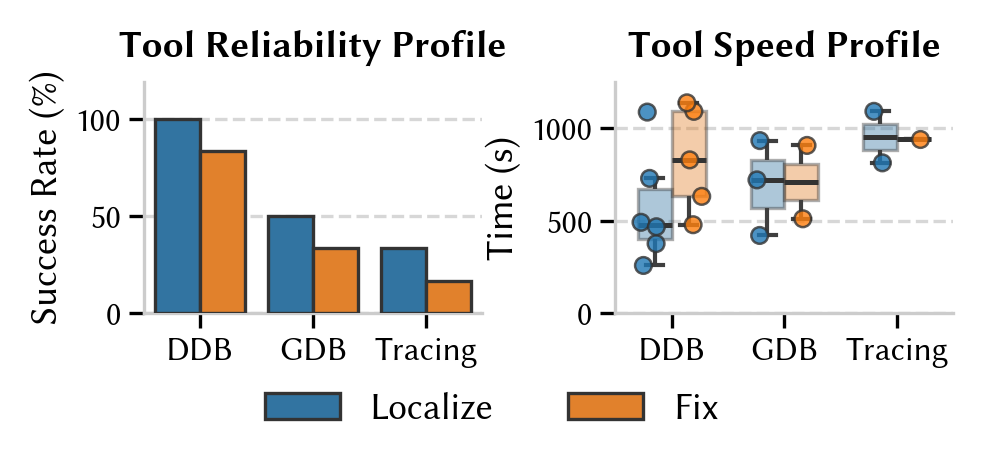

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hardcoded ACM width in inches
width = plot_style_apply(template="acm", span=False, usetex=False)

# --- 1. STRICTLY YOUR REAL DATA ONLY ---
raw_data = [
    # --- User 1 ---
    [1, "DDB",     258,    478],
    [1, "Tracing", None,   None],
    [1, "GDB",     420,    510],

    # --- User 2 ---
    [2, "GDB",     None,   None],
    [2, "DDB",     376,    1090],
    [2, "Tracing", 1090,   None],

    # --- User 3 ---
    [3, "Tracing", None,   None],
    [3, "GDB",     None,   None],
    [3, "DDB",     728,    None],
    
    # --- User 4 ---
    [4, "DDB",     491,    828],
    [4, "Tracing", 812,   940],
    [4, "GDB",     None,    None],

    # --- User 5 ---
    [5, "GDB",     932,   None],
    [5, "DDB",     467,    631],
    [5, "Tracing", None,   None],
    
    # --- User 6 ---
    [6, "Tracing", None,   None],
    [6, "GDB",     720,   906],
    [6, "DDB",     1086,    1136],
]

# --- 2. AUTOMATIC DATA PROCESSING ---
df_wide = pd.DataFrame(raw_data, columns=["User_ID", "System", "Localize", "Fix"])

df = df_wide.melt(
    id_vars=["User_ID", "System"], 
    value_vars=["Localize", "Fix"], 
    var_name="Stage", 
    value_name="Time"
)

df["Success"] = df["Time"].notna().astype(int)

success_df = df.groupby(["System", "Stage"])["Success"].mean().reset_index()
success_df["Success Rate (%)"] = success_df["Success"] * 100

# Swapped the conceptual focus
system_order = ["DDB", "GDB", "Tracing"]
stage_order = ["Localize", "Fix"]

# New Colors: Deep Blue for Localize, Vibrant Orange for Fix
task_colors = ["#1F77B4", "#FF7F0E"] 
edge_color = "#333333" 

# --- 3. FIGURE SETUP ---
fig, axes = plt.subplots(1, 2, figsize=(width, 1.5), gridspec_kw={'width_ratios': [1, 1]})

# --- Plot A: Success Rates (Grouped by System) ---
sns.barplot(
    data=success_df, x="System", y="Success Rate (%)", hue="Stage", 
    order=system_order, hue_order=stage_order, # X is now System
    ax=axes[0], palette=task_colors, edgecolor=edge_color, linewidth=0.8, zorder=3
)
axes[0].set_ylim(0, 119) 
axes[0].set_ylabel("Success Rate (%)", weight="medium", fontsize=9, labelpad=2)
axes[0].set_xlabel("")
axes[0].set_title("Tool Reliability Profile", fontsize=9, weight="bold")
axes[0].grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

axes[0].tick_params(axis="both", labelsize=8, pad=2)

# for p in axes[0].patches:
#     height = p.get_height()
#     if height > 0: 
#         axes[0].annotate(f'{height:.0f}%', 
#                          (p.get_x() + p.get_width() / 2., height), 
#                          ha='center', va='bottom', fontsize=6, color=edge_color,
#                          xytext=(0, 2), textcoords='offset points')

# --- Plot B: Completion Times (Grouped by System) ---
sns.boxplot(
    data=df, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True, # X is now System
    ax=axes[1], palette=task_colors, showfliers=False, width=0.6,
    boxprops=dict(alpha=0.4, edgecolor=edge_color, linewidth=0.8),
    medianprops=dict(color=edge_color, linewidth=1.2), zorder=2
)
sns.stripplot(
    data=df, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, edgecolor=edge_color, 
    linewidth=0.6, size=4, alpha=0.8, jitter=0.15, zorder=4
)

max_time = df["Time"].max()
if pd.isna(max_time): max_time = 1200 
axes[1].set_ylim(0, max_time * 1.1)

axes[1].set_ylabel("Time (s)", weight="medium", fontsize=9, labelpad=2)
axes[1].set_xlabel("")
axes[1].set_title("Tool Speed Profile", fontsize=9, weight="bold")
axes[1].grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

axes[1].tick_params(axis="both", labelsize=8, pad=2)

# --- 4. CLEAN UP ---
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.set_axisbelow(True) 

axes[0].get_legend().remove()
axes[1].get_legend().remove()

# Legend now represents the Tasks, so we only need 2 items
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], loc='lower center', bbox_to_anchor=(0.5, -0.05), 
           ncol=2, frameon=False, fontsize=9)

plt.tight_layout(w_pad=0.1) 
fig.subplots_adjust(bottom=0.28) 

fig.savefig("tool_centric_profile.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

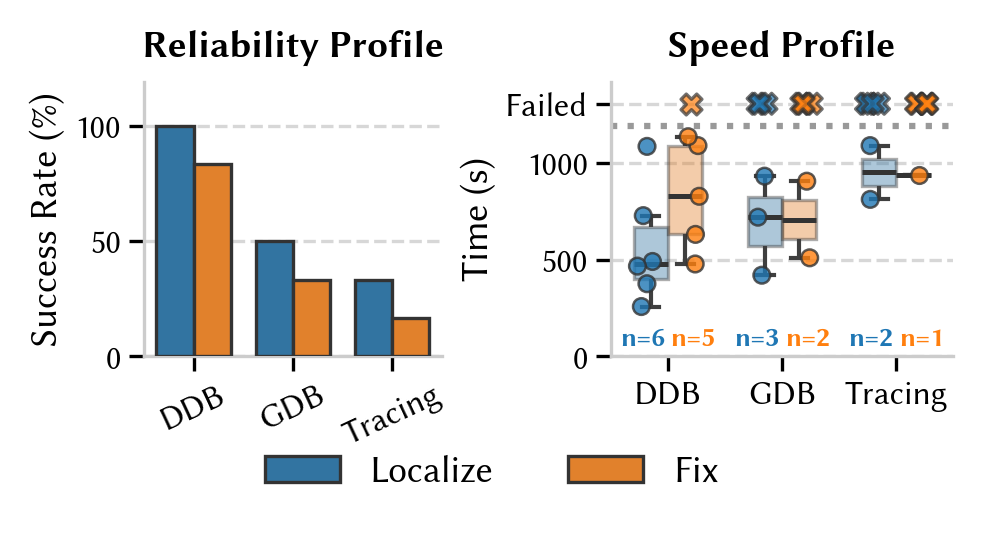

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker 

# Hardcoded ACM width in inches (with a fallback just in case)
try:
    width = plot_style_apply(template="acm", span=False, usetex=False)
except NameError:
    width = 3.33 # Standard ACM single-column width

# --- 1. STRICTLY YOUR REAL DATA ONLY ---
raw_data = [
    [1, "DDB",     258,    478],
    [1, "Tracing", None,   None],
    [1, "GDB",     420,    510],
    [2, "GDB",     None,   None],
    [2, "DDB",     376,    1090],
    [2, "Tracing", 1090,   None],
    [3, "Tracing", None,   None],
    [3, "GDB",     None,   None],
    [3, "DDB",     728,    None],
    [4, "DDB",     491,    828],
    [4, "Tracing", 812,   940],
    [4, "GDB",     None,    None],
    [5, "GDB",     932,   None],
    [5, "DDB",     467,    631],
    [5, "Tracing", None,   None],
    [6, "Tracing", None,   None],
    [6, "GDB",     720,   906],
    [6, "DDB",     1086,    1136],
]

# --- 2. AUTOMATIC DATA PROCESSING ---
df_wide = pd.DataFrame(raw_data, columns=["User_ID", "System", "Localize", "Fix"])

df = df_wide.melt(
    id_vars=["User_ID", "System"], 
    value_vars=["Localize", "Fix"], 
    var_name="Stage", 
    value_name="Time"
)

df["Success"] = df["Time"].notna().astype(int)

success_df = df.groupby(["System", "Stage"])["Success"].mean().reset_index()
success_df["Success Rate (%)"] = success_df["Success"] * 100

system_order = ["DDB", "GDB", "Tracing"]
stage_order = ["Localize", "Fix"]

task_colors = ["#1F77B4", "#FF7F0E"] 
edge_color = "#333333" 

# --- 3. FIGURE SETUP ---
# Adjusted ratio to give the left plot a fair share of space
fig, axes = plt.subplots(1, 2, figsize=(width, 1.7), gridspec_kw={'width_ratios': [1.0, 1.15]})

# --- Plot A: Success Rates (Grouped by System) ---
sns.barplot(
    data=success_df, x="System", y="Success Rate (%)", hue="Stage", 
    order=system_order, hue_order=stage_order, 
    ax=axes[0], palette=task_colors, edgecolor=edge_color, linewidth=0.8, 
    zorder=3, width=0.75 # Added width=0.75 to slim the bars down slightly
)
axes[0].set_ylim(0, 119) 
axes[0].set_ylabel("Success Rate (%)", weight="medium", fontsize=9, labelpad=2)
axes[0].set_xlabel("")
axes[0].set_title("Reliability Profile", fontsize=9, weight="bold")
axes[0].grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

axes[0].tick_params(axis="y", labelsize=8, pad=2)
# Rotated X-axis labels to prevent text crowding
axes[0].tick_params(axis="x", labelsize=8, pad=2, labelrotation=25) 

# --- Plot B: Completion Times (Grouped by System) ---
sns.boxplot(
    data=df, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, showfliers=False, width=0.6,
    boxprops=dict(alpha=0.4, edgecolor=edge_color, linewidth=0.8),
    medianprops=dict(color=edge_color, linewidth=1.2), zorder=2
)
sns.stripplot(
    data=df, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, edgecolor=edge_color, 
    linewidth=0.6, size=4, alpha=0.8, jitter=0.15, zorder=4
)

max_time = df["Time"].max()
if pd.isna(max_time): max_time = 1200 
fail_y = max_time * 1.15  

df_fails = df[df["Time"].isna()].copy()
df_fails["Time"] = fail_y 

sns.stripplot(
    data=df_fails, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, edgecolor=edge_color, 
    linewidth=0.8, size=5, marker="X", alpha=0.7, jitter=0.15, zorder=5
)

axes[1].axhline(y=max_time * 1.05, color='#999999', linestyle=':', linewidth=1.5, zorder=1)
axes[1].set_ylim(0, max_time * 1.25)

current_yticks = axes[1].get_yticks()
clean_yticks = [y for y in current_yticks if y <= max_time] + [fail_y]
axes[1].set_yticks(clean_yticks)

def format_y(val, pos):
    if val == fail_y: return "Failed"
    return f"{int(val)}"
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(format_y))

# Restored labelpad to 6 to push the Y-axis label safely away
axes[1].set_ylabel("Time (s)", weight="medium", fontsize=9, labelpad=2)
axes[1].set_xlabel("")
axes[1].set_title("Speed Profile", fontsize=9, weight="bold")
axes[1].grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

axes[1].tick_params(axis="y", labelsize=8, pad=2)
axes[1].tick_params(axis="x", labelsize=8, pad=2)

for i, system in enumerate(system_order):
    for j, stage in enumerate(stage_order):
        subset = df[(df["System"] == system) & (df["Stage"] == stage)]
        n_success = subset["Time"].notna().sum()
        
        x_pos = i - 0.22 if j == 0 else i + 0.22
        text_color = task_colors[j] 
        
        axes[1].text(
            x_pos, max_time * 0.02, f"n={n_success}", 
            ha='center', va='bottom', fontsize=6.5, color=text_color, 
            weight='bold', zorder=6
        )

# --- 4. CLEAN UP ---
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.set_axisbelow(True) 

axes[0].get_legend().remove()
axes[1].get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], loc='lower center', bbox_to_anchor=(0.5, -0.05), 
           ncol=2, frameon=False, fontsize=9)

# Shrunk w_pad to 0.5 to gain more graph width, since we fixed text overlaps!
plt.tight_layout(w_pad=0.5) 
fig.subplots_adjust(bottom=0.28) 

fig.savefig("tool_centric_profile.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

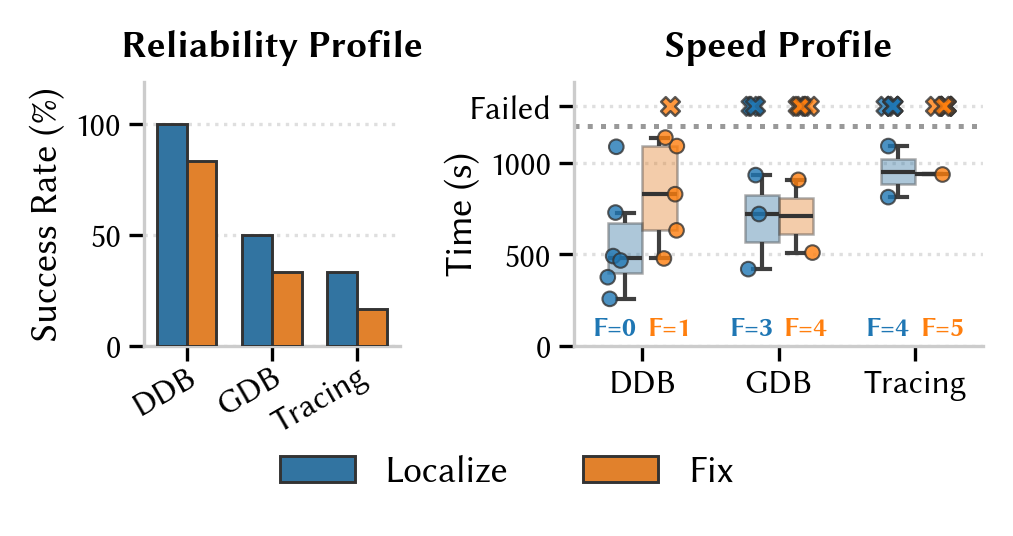

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker 

# Hardcoded ACM width in inches
try:
    width = plot_style_apply(template="acm", span=False, usetex=False) + 0.1
except NameError:
    width = 3.33 

# --- 1. STRICTLY YOUR REAL DATA ONLY ---
raw_data = [
    [1, "DDB",     258,    478],
    [1, "Tracing", None,   None],
    [1, "GDB",     420,    510],
    [2, "GDB",     None,   None],
    [2, "DDB",     376,    1090],
    [2, "Tracing", 1090,   None],
    [3, "Tracing", None,   None],
    [3, "GDB",     None,   None],
    [3, "DDB",     728,    None],
    [4, "DDB",     491,    828],
    [4, "Tracing", 812,   940],
    [4, "GDB",     None,    None],
    [5, "GDB",     932,   None],
    [5, "DDB",     467,    631],
    [5, "Tracing", None,   None],
    [6, "Tracing", None,   None],
    [6, "GDB",     720,   906],
    [6, "DDB",     1086,    1136],
]

# --- 2. AUTOMATIC DATA PROCESSING ---
df_wide = pd.DataFrame(raw_data, columns=["User_ID", "System", "Localize", "Fix"])

df = df_wide.melt(
    id_vars=["User_ID", "System"], 
    value_vars=["Localize", "Fix"], 
    var_name="Stage", 
    value_name="Time"
)

df["Success"] = df["Time"].notna().astype(int)

success_df = df.groupby(["System", "Stage"])["Success"].mean().reset_index()
success_df["Success Rate (%)"] = success_df["Success"] * 100

system_order = ["DDB", "GDB", "Tracing"]
stage_order = ["Localize", "Fix"]

task_colors = ["#1F77B4", "#FF7F0E"] 
edge_color = "#333333" 

# --- 3. FIGURE SETUP ---
fig, axes = plt.subplots(1, 2, figsize=(width, 1.7), gridspec_kw={'width_ratios': [1, 1.6]})

# --- Plot A: Success Rates ---
sns.barplot(
    data=success_df, x="System", y="Success Rate (%)", hue="Stage", 
    order=system_order, hue_order=stage_order, 
    ax=axes[0], palette=task_colors, edgecolor=edge_color, linewidth=0.7, 
    zorder=3, width=0.7 
)
axes[0].set_ylim(0, 119) 
axes[0].set_yticks([0, 50, 100])
axes[0].set_ylabel("Success Rate (%)", weight="medium", fontsize=9, labelpad=2)
axes[0].set_xlabel("")
axes[0].set_title("Reliability Profile", fontsize=9, weight="bold")
axes[0].grid(axis="y", linestyle=":", alpha=0.4, zorder=0)

axes[0].tick_params(axis="y", labelsize=8, pad=2)

axes[0].set_xticks(range(len(system_order)))
axes[0].set_xticklabels(system_order, rotation=30, ha='right', rotation_mode="anchor")
axes[0].tick_params(axis="x", labelsize=8, pad=0) 

# --- Plot B: Completion Times ---
sns.boxplot(
    data=df, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, showfliers=False, width=0.5,
    boxprops=dict(alpha=0.4, edgecolor=edge_color, linewidth=0.6),
    medianprops=dict(color=edge_color, linewidth=1.0), zorder=2
)
sns.stripplot(
    data=df, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, edgecolor=edge_color, 
    linewidth=0.5, size=3.5, alpha=0.8, jitter=0.12, zorder=4
)

max_time = df["Time"].max()
if pd.isna(max_time): max_time = 1200 
fail_y = max_time * 1.15  

df_fails = df[df["Time"].isna()].copy()
df_fails["Time"] = fail_y 

sns.stripplot(
    data=df_fails, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, edgecolor=edge_color, 
    linewidth=0.6, size=4.5, marker="X", alpha=0.8, jitter=0.12, zorder=5
)

axes[1].axhline(y=1200, color='#999999', linestyle=':', linewidth=1.2, zorder=1)
axes[1].set_ylim(0, 1200 * 1.2)

axes[1].set_yticks([0, 500, 1000, fail_y])

def format_y(val, pos):
    if val == fail_y: return "Failed"
    return f"{int(val)}"
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(format_y))

axes[1].set_ylabel("Time (s)", weight="medium", fontsize=9, labelpad=-3)
axes[1].set_xlabel("")
axes[1].set_title("Speed Profile", fontsize=9, weight="bold")
axes[1].grid(axis="y", linestyle=":", alpha=0.4, zorder=0)

axes[1].tick_params(axis="y", labelsize=8, pad=2)
axes[1].tick_params(axis="x", labelsize=8, pad=2)

for i, system in enumerate(system_order):
    for j, stage in enumerate(stage_order):
        subset = df[(df["System"] == system) & (df["Stage"] == stage)]
        # Count the number of NaNs (failures)
        n_fails = subset["Time"].isna().sum() 
        
        x_pos = i - 0.20 if j == 0 else i + 0.20
        text_color = task_colors[j] 
        
        axes[1].text(
            x_pos, max_time * 0.02, f"F={n_fails}", 
            ha='center', va='bottom', fontsize=6.5, color=text_color, 
            weight='bold', zorder=6
        )

# --- 4. CLEAN UP ---
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.set_axisbelow(True) 

axes[0].get_legend().remove()
axes[1].get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], loc='lower center', bbox_to_anchor=(0.5, -0.05), 
           ncol=2, frameon=False, fontsize=9)

plt.tight_layout(w_pad=1.2) 
fig.subplots_adjust(bottom=0.3) 

fig.savefig("tool_centric_profile.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

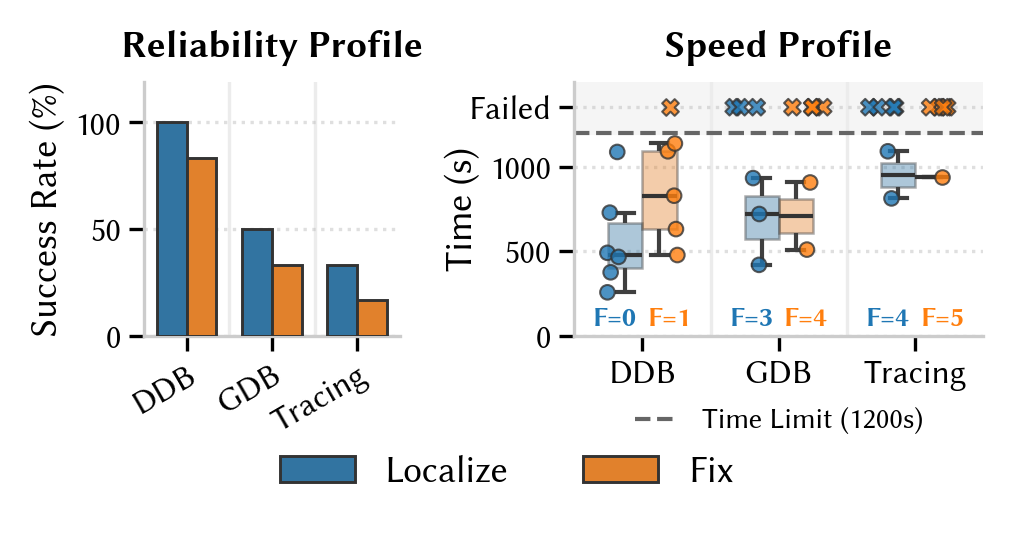

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker 
from matplotlib.lines import Line2D # Added for custom legend handle

# Hardcoded ACM width in inches
try:
    width = plot_style_apply(template="acm", span=False, usetex=False) + 0.1
except NameError:
    width = 3.33 

# --- 1. STRICTLY YOUR REAL DATA ONLY ---
raw_data = [
    [1, "DDB",     258,    478],
    [1, "Tracing", None,   None],
    [1, "GDB",     420,    510],
    [2, "GDB",     None,   None],
    [2, "DDB",     376,    1090],
    [2, "Tracing", 1090,   None],
    [3, "Tracing", None,   None],
    [3, "GDB",     None,   None],
    [3, "DDB",     728,    None],
    [4, "DDB",     491,    828],
    [4, "Tracing", 812,   940],
    [4, "GDB",     None,    None],
    [5, "GDB",     932,   None],
    [5, "DDB",     467,    631],
    [5, "Tracing", None,   None],
    [6, "Tracing", None,   None],
    [6, "GDB",     720,   906],
    [6, "DDB",     1086,    1136],
]

# --- 2. AUTOMATIC DATA PROCESSING ---
df_wide = pd.DataFrame(raw_data, columns=["User_ID", "System", "Localize", "Fix"])

df = df_wide.melt(
    id_vars=["User_ID", "System"], 
    value_vars=["Localize", "Fix"], 
    var_name="Stage", 
    value_name="Time"
)

df["Success"] = df["Time"].notna().astype(int)

success_df = df.groupby(["System", "Stage"])["Success"].mean().reset_index()
success_df["Success Rate (%)"] = success_df["Success"] * 100

system_order = ["DDB", "GDB", "Tracing"]
stage_order = ["Localize", "Fix"]

task_colors = ["#1F77B4", "#FF7F0E"] 
edge_color = "#333333" 

# --- 3. FIGURE SETUP ---
fig, axes = plt.subplots(1, 2, figsize=(width, 1.7), gridspec_kw={'width_ratios': [1, 1.6]})

# --- Plot A: Success Rates ---
sns.barplot(
    data=success_df, x="System", y="Success Rate (%)", hue="Stage", 
    order=system_order, hue_order=stage_order, 
    ax=axes[0], palette=task_colors, edgecolor=edge_color, linewidth=0.7, 
    zorder=3, width=0.7 
)
axes[0].set_ylim(0, 119) 
axes[0].set_yticks([0, 50, 100])
axes[0].set_ylabel("Success Rate (%)", weight="medium", fontsize=9, labelpad=2)
axes[0].set_xlabel("")
axes[0].set_title("Reliability Profile", fontsize=9, weight="bold")
axes[0].grid(axis="y", linestyle=":", alpha=0.4, zorder=0)

axes[0].tick_params(axis="y", labelsize=8, pad=2)

axes[0].set_xticks(range(len(system_order)))
axes[0].set_xticklabels(system_order, rotation=30, ha='right', rotation_mode="anchor")
axes[0].tick_params(axis="x", labelsize=8, pad=0) 

# --- Plot B: Completion Times ---
sns.boxplot(
    data=df, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, showfliers=False, width=0.5,
    boxprops=dict(alpha=0.4, edgecolor=edge_color, linewidth=0.6),
    medianprops=dict(color=edge_color, linewidth=1.0), zorder=2
)
sns.stripplot(
    data=df, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, edgecolor=edge_color, 
    linewidth=0.5, size=3.5, alpha=0.8, jitter=0.12, zorder=4
)

max_time = df["Time"].max()
if pd.isna(max_time): max_time = 1200 
fail_y = 1350

df_fails = df[df["Time"].isna()].copy()
df_fails["Time"] = fail_y 

sns.stripplot(
    data=df_fails, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, edgecolor=edge_color, 
    linewidth=0.5, size=4, marker="X", alpha=0.8, jitter=0.3, zorder=5
)

for ax in axes:
    ax.axhspan(1200, 1500, color="#f5f5f5", zorder=0)
    # ax.axhline(y=max_time * 1.05, color='#999999', linestyle=':', linewidth=1.2, zorder=1)
    
    ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.set_axisbelow(True) 
    
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=8, pad=2)

    ax.axvline(x=0.5, color="#ECECEC", linestyle='-', linewidth=0.8, zorder=0)
    ax.axvline(x=1.5, color='#ECECEC', linestyle='-', linewidth=0.8, zorder=0)

# UPDATED: Thicker, darker dashed line for the time limit
axes[1].axhline(y=1200 , color='#666666', linestyle='--', linewidth=1, zorder=1)
axes[1].set_ylim(0, 1500)

axes[1].set_yticks([0, 500, 1000, fail_y])

def format_y(val, pos):
    if val == fail_y: return "Failed"
    return f"{int(val)}"
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(format_y))

axes[1].set_ylabel("Time (s)", weight="medium", fontsize=9, labelpad=-3)
axes[1].set_xlabel("")
axes[1].set_title("Speed Profile", fontsize=9, weight="bold")
axes[1].grid(axis="y", linestyle=":", alpha=0.4, zorder=0)

axes[1].tick_params(axis="y", labelsize=8, pad=2)
axes[1].tick_params(axis="x", labelsize=8, pad=2)

for i, system in enumerate(system_order):
    for j, stage in enumerate(stage_order):
        subset = df[(df["System"] == system) & (df["Stage"] == stage)]
        # Count the number of NaNs (failures)
        n_fails = subset["Time"].isna().sum() 
        
        x_pos = i - 0.20 if j == 0 else i + 0.20
        text_color = task_colors[j] 
        
        axes[1].text(
            x_pos, max_time * 0.02, f"F={n_fails}", 
            ha='center', va='bottom', fontsize=6.5, color=text_color, 
            weight='bold', zorder=6
        )

# --- 4. CLEAN UP ---
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.set_axisbelow(True) 

# Remove the default seaborn legends
axes[0].get_legend().remove()
axes[1].get_legend().remove()

# --- Global Legend (Localize & Fix) ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], loc='lower center', bbox_to_anchor=(0.5, -0.05), 
           ncol=2, frameon=False, fontsize=9)

# --- Right Plot Legend (Time Limit) ---
# UPDATED: Matches the new thicker, darker dashed line style
time_limit_handle = Line2D([0], [0], color='#666666', linestyle='--', linewidth=1)
axes[1].legend([time_limit_handle], ['Time Limit (1200s)'], 
               loc='upper center', bbox_to_anchor=(0.5, -0.18), 
               frameon=False, fontsize=7, handlelength=1.5)

plt.tight_layout(w_pad=1.2) 
fig.subplots_adjust(bottom=0.32) 

fig.savefig("tool_centric_profile.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

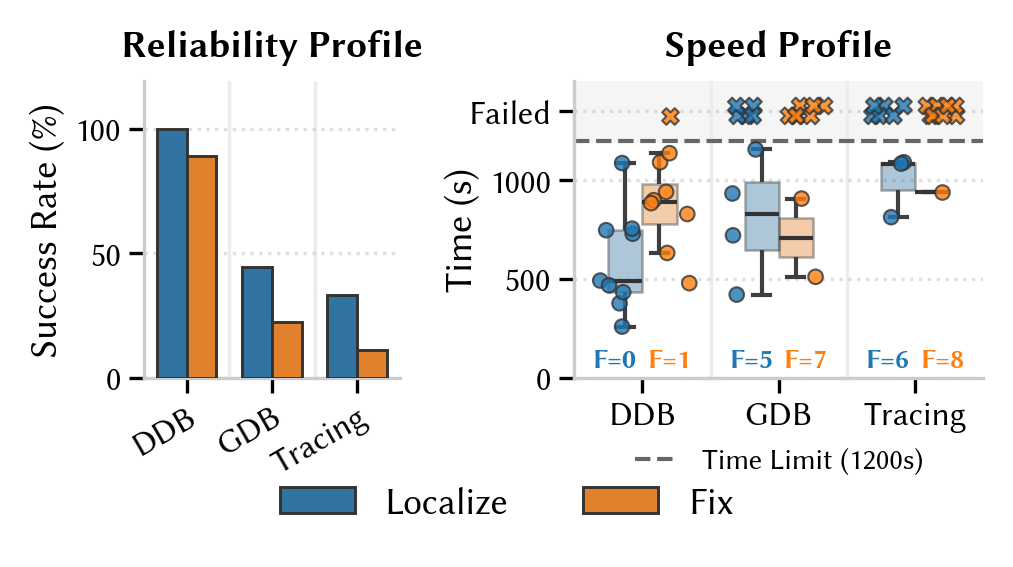

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker 
from matplotlib.lines import Line2D 

# Hardcoded ACM width in inches
try:
    width = plot_style_apply(template="acm", span=False, usetex=False) + 0.1
except NameError:
    width = 3.33 

# --- 1. STRICTLY YOUR REAL DATA ONLY ---
raw_data = [
    [1, "DDB",     258,    478],
    [1, "Tracing", None,   None],
    [1, "GDB",     420,    510],

    [2, "GDB",     None,   None],
    [2, "DDB",     376,    1090],
    [2, "Tracing", 1090,   None],

    [3, "Tracing", None,   None],
    [3, "GDB",     None,   None],
    [3, "DDB",     728,    None],

    [4, "DDB",     491,    828],
    [4, "Tracing", 812,   940],
    [4, "GDB",     None,    None],

    [5, "GDB",     932,   None],
    [5, "DDB",     467,    631],
    [5, "Tracing", None,   None],

    [6, "Tracing", None,   None],
    [6, "GDB",     720,   906],
    [6, "DDB",     1086,    1136],

    [7, "DDB",     432,    940],
    [7, "Tracing", 1083,   None],
    [7, "GDB",     None,    None],

    [8, "GDB",     None,   None],
    [8, "DDB",     746,    898],
    [8, "Tracing", None,   None],
    
    [9, "Tracing", None,   None],
    [9, "GDB",     1155,   None],
    [9, "DDB",     754,    883],
]

# --- 2. AUTOMATIC DATA PROCESSING ---
df_wide = pd.DataFrame(raw_data, columns=["User_ID", "System", "Localize", "Fix"])

df = df_wide.melt(
    id_vars=["User_ID", "System"], 
    value_vars=["Localize", "Fix"], 
    var_name="Stage", 
    value_name="Time"
)

df["Success"] = df["Time"].notna().astype(int)

success_df = df.groupby(["System", "Stage"])["Success"].mean().reset_index()
success_df["Success Rate (%)"] = success_df["Success"] * 100

system_order = ["DDB", "GDB", "Tracing"]
stage_order = ["Localize", "Fix"]

task_colors = ["#1F77B4", "#FF7F0E"] 
edge_color = "#333333" 

# --- 3. FIGURE SETUP ---
fig, axes = plt.subplots(1, 2, figsize=(width, 1.8), gridspec_kw={'width_ratios': [1, 1.6]})

# --- Plot A: Success Rates ---
sns.barplot(
    data=success_df, x="System", y="Success Rate (%)", hue="Stage", 
    order=system_order, hue_order=stage_order, 
    ax=axes[0], palette=task_colors, edgecolor=edge_color, linewidth=0.7, 
    zorder=3, width=0.7 
)
axes[0].set_ylim(0, 119) 
axes[0].set_yticks([0, 50, 100])
axes[0].set_ylabel("Success Rate (%)", weight="medium", fontsize=9, labelpad=2)
axes[0].set_xlabel("")
axes[0].set_title("Reliability Profile", fontsize=9, weight="bold")
axes[0].grid(axis="y", linestyle=":", alpha=0.4, zorder=0)

axes[0].tick_params(axis="y", labelsize=8, pad=2)

axes[0].set_xticks(range(len(system_order)))
axes[0].set_xticklabels(system_order, rotation=30, ha='right', rotation_mode="anchor")
axes[0].tick_params(axis="x", labelsize=8, pad=0) 

# --- Plot B: Completion Times ---
sns.boxplot(
    data=df, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, showfliers=False, width=0.5,
    boxprops=dict(alpha=0.4, edgecolor=edge_color, linewidth=0.6),
    medianprops=dict(color=edge_color, linewidth=1.0), zorder=2
)
sns.stripplot(
    data=df, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, edgecolor=edge_color, 
    linewidth=0.5, size=3.5, alpha=0.8, jitter=0.3, zorder=4
)

max_time = df["Time"].max()
if pd.isna(max_time): max_time = 1200 
fail_y = 1350

# --- UPDATED: Two-row layout for failures ---
df_fails = df[df["Time"].isna()].copy()
df_fails["fail_idx"] = df_fails.groupby(["System", "Stage"]).cumcount()
y_offset = 25 
df_fails["Time"] = fail_y - y_offset + (df_fails["fail_idx"] % 2) * (y_offset * 2)

sns.stripplot(
    data=df_fails, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, edgecolor=edge_color, 
    linewidth=0.5, size=4, marker="X", alpha=0.8, jitter=0.3, zorder=5
)

for ax in axes:
    ax.axhspan(1200, 1500, color="#f5f5f5", zorder=0)
    
    ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.set_axisbelow(True) 
    
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=8, pad=2)

    ax.axvline(x=0.5, color="#ECECEC", linestyle='-', linewidth=0.8, zorder=0)
    ax.axvline(x=1.5, color='#ECECEC', linestyle='-', linewidth=0.8, zorder=0)

axes[1].axhline(y=1200 , color='#666666', linestyle='--', linewidth=1, zorder=1)
axes[1].set_ylim(0, 1500)

axes[1].set_yticks([0, 500, 1000, fail_y])

def format_y(val, pos):
    if val == fail_y: return "Failed"
    return f"{int(val)}"
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(format_y))

axes[1].set_ylabel("Time (s)", weight="medium", fontsize=9, labelpad=-3)
axes[1].set_xlabel("")
axes[1].set_title("Speed Profile", fontsize=9, weight="bold")
axes[1].grid(axis="y", linestyle=":", alpha=0.4, zorder=0)

axes[1].tick_params(axis="y", labelsize=8, pad=2)
axes[1].tick_params(axis="x", labelsize=8, pad=2)

for i, system in enumerate(system_order):
    for j, stage in enumerate(stage_order):
        subset = df[(df["System"] == system) & (df["Stage"] == stage)]
        n_fails = subset["Time"].isna().sum() 
        
        x_pos = i - 0.20 if j == 0 else i + 0.20
        text_color = task_colors[j] 
        
        axes[1].text(
            x_pos, max_time * 0.02, f"F={n_fails}", 
            ha='center', va='bottom', fontsize=6.5, color=text_color, 
            weight='bold', zorder=6
        )

# --- 4. CLEAN UP ---
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.set_axisbelow(True) 

# Remove the default seaborn legends
axes[0].get_legend().remove()
axes[1].get_legend().remove()

# --- Global Legend (Localize & Fix) ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], loc='lower center', bbox_to_anchor=(0.5, -0.05), 
           ncol=2, frameon=False, fontsize=9)

# --- Right Plot Legend (Time Limit) ---
time_limit_handle = Line2D([0], [0], color='#666666', linestyle='--', linewidth=1)
axes[1].legend([time_limit_handle], ['Time Limit (1200s)'], 
               loc='upper center', bbox_to_anchor=(0.5, -0.15), 
               frameon=False, fontsize=7, handlelength=1.5)

plt.tight_layout(w_pad=1.2) 
fig.subplots_adjust(bottom=0.28) 

fig.savefig("tool_centric_profile.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

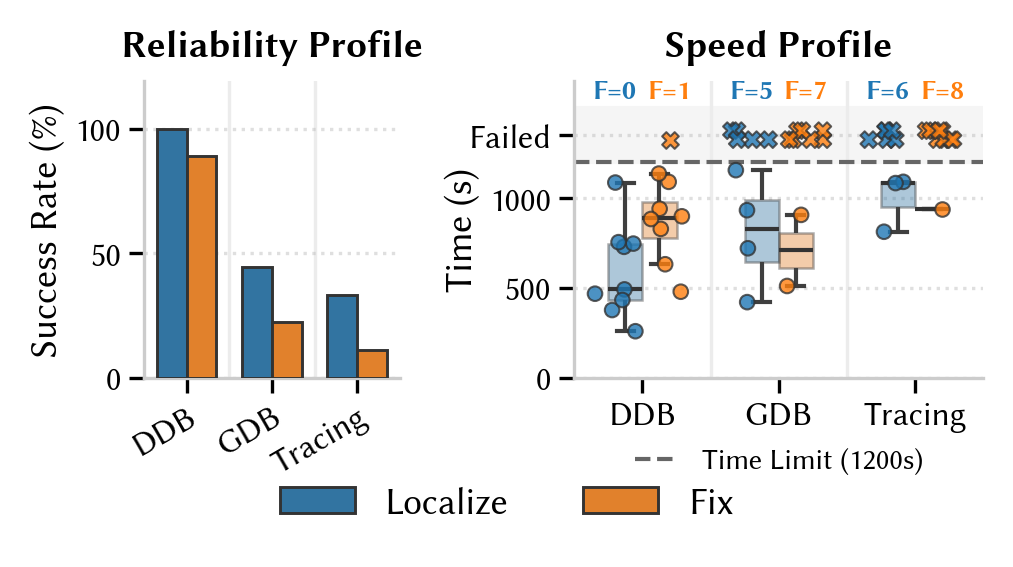

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker 
from matplotlib.lines import Line2D 

# Hardcoded ACM width in inches
try:
    width = plot_style_apply(template="acm", span=False, usetex=False) + 0.1
except NameError:
    width = 3.33 

# --- 1. STRICTLY YOUR REAL DATA ONLY ---
raw_data = [
    [1, "DDB",     258,    478],
    [1, "Tracing", None,   None],
    [1, "GDB",     420,    510],

    [2, "GDB",     None,   None],
    [2, "DDB",     376,    1090],
    [2, "Tracing", 1090,   None],

    [3, "Tracing", None,   None],
    [3, "GDB",     None,   None],
    [3, "DDB",     728,    None],

    [4, "DDB",     491,    828],
    [4, "Tracing", 812,   940],
    [4, "GDB",     None,    None],

    [5, "GDB",     932,   None],
    [5, "DDB",     467,    631],
    [5, "Tracing", None,   None],

    [6, "Tracing", None,   None],
    [6, "GDB",     720,   906],
    [6, "DDB",     1086,    1136],

    [7, "DDB",     432,    940],
    [7, "Tracing", 1083,   None],
    [7, "GDB",     None,    None],

    [8, "GDB",     None,   None],
    [8, "DDB",     746,    898],
    [8, "Tracing", None,   None],
    
    [9, "Tracing", None,   None],
    [9, "GDB",     1155,   None],
    [9, "DDB",     754,    883],
]

# --- 2. AUTOMATIC DATA PROCESSING ---
df_wide = pd.DataFrame(raw_data, columns=["User_ID", "System", "Localize", "Fix"])

df = df_wide.melt(
    id_vars=["User_ID", "System"], 
    value_vars=["Localize", "Fix"], 
    var_name="Stage", 
    value_name="Time"
)

df["Success"] = df["Time"].notna().astype(int)

success_df = df.groupby(["System", "Stage"])["Success"].mean().reset_index()
success_df["Success Rate (%)"] = success_df["Success"] * 100

system_order = ["DDB", "GDB", "Tracing"]
stage_order = ["Localize", "Fix"]

task_colors = ["#1F77B4", "#FF7F0E"] 
edge_color = "#333333" 

# --- 3. FIGURE SETUP ---
fig, axes = plt.subplots(1, 2, figsize=(width, 1.8), gridspec_kw={'width_ratios': [1, 1.6]})

# --- Plot A: Success Rates ---
sns.barplot(
    data=success_df, x="System", y="Success Rate (%)", hue="Stage", 
    order=system_order, hue_order=stage_order, 
    ax=axes[0], palette=task_colors, edgecolor=edge_color, linewidth=0.7, 
    zorder=3, width=0.7 
)
axes[0].set_ylim(0, 119) 
axes[0].set_yticks([0, 50, 100])
axes[0].set_ylabel("Success Rate (%)", weight="medium", fontsize=9, labelpad=2)
axes[0].set_xlabel("")
axes[0].set_title("Reliability Profile", fontsize=9, weight="bold")
axes[0].grid(axis="y", linestyle=":", alpha=0.4, zorder=0)

axes[0].tick_params(axis="y", labelsize=8, pad=2)

axes[0].set_xticks(range(len(system_order)))
axes[0].set_xticklabels(system_order, rotation=30, ha='right', rotation_mode="anchor")
axes[0].tick_params(axis="x", labelsize=8, pad=0) 

# --- Plot B: Completion Times ---
sns.boxplot(
    data=df, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, showfliers=False, width=0.5,
    boxprops=dict(alpha=0.4, edgecolor=edge_color, linewidth=0.6),
    medianprops=dict(color=edge_color, linewidth=1.0), zorder=2
)
sns.stripplot(
    data=df, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, edgecolor=edge_color, 
    linewidth=0.5, size=3.5, alpha=0.8, jitter=0.3, zorder=4
)

max_time = df["Time"].max()
if pd.isna(max_time): max_time = 1200 
fail_y = 1350

# --- Two-row layout for failures ---
df_fails = df[df["Time"].isna()].copy()
df_fails["fail_idx"] = df_fails.groupby(["System", "Stage"]).cumcount()
y_offset = 25 
df_fails["Time"] = fail_y - y_offset + (df_fails["fail_idx"] % 2) * (y_offset * 2)

sns.stripplot(
    data=df_fails, x="System", y="Time", hue="Stage",
    order=system_order, hue_order=stage_order, dodge=True,
    ax=axes[1], palette=task_colors, edgecolor=edge_color, 
    linewidth=0.5, size=4, marker="X", alpha=0.8, jitter=0.3, zorder=5
)

for ax in axes:
    # Grey box still safely stops at 1500
    ax.axhspan(1200, 1500, color="#f5f5f5", zorder=0) 
    
    ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.set_axisbelow(True) 
    
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=8, pad=2)

    ax.axvline(x=0.5, color="#ECECEC", linestyle='-', linewidth=0.8, zorder=0)
    ax.axvline(x=1.5, color='#ECECEC', linestyle='-', linewidth=0.8, zorder=0)

axes[1].axhline(y=1200 , color='#666666', linestyle='--', linewidth=1, zorder=1)

# --- UPDATED: Extended Y-axis to 1650 to create white space above grey box ---
axes[1].set_ylim(0, 1650) 

axes[1].set_yticks([0, 500, 1000, fail_y])

def format_y(val, pos):
    if val == fail_y: return "Failed"
    return f"{int(val)}"
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(format_y))

axes[1].set_ylabel("Time (s)", weight="medium", fontsize=9, labelpad=-3)
axes[1].set_xlabel("")
axes[1].set_title("Speed Profile", fontsize=9, weight="bold")
axes[1].grid(axis="y", linestyle=":", alpha=0.4, zorder=0)

axes[1].tick_params(axis="y", labelsize=8, pad=2)
axes[1].tick_params(axis="x", labelsize=8, pad=2)

# --- UPDATED: Placed labels in the new white space gap ---
for i, system in enumerate(system_order):
    for j, stage in enumerate(stage_order):
        subset = df[(df["System"] == system) & (df["Stage"] == stage)]
        n_fails = subset["Time"].isna().sum() 
        
        x_pos = i - 0.20 if j == 0 else i + 0.20
        text_color = task_colors[j] 
        
        axes[1].text(
            x_pos, 1520, f"F={n_fails}", # Y coordinate lands in the blank gap
            ha='center', va='bottom', fontsize=6.5, color=text_color, 
            weight='bold', zorder=6
        )

# --- 4. CLEAN UP ---
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.set_axisbelow(True) 

# Remove the default seaborn legends
axes[0].get_legend().remove()
axes[1].get_legend().remove()

# --- Global Legend (Localize & Fix) ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], loc='lower center', bbox_to_anchor=(0.5, -0.05), 
           ncol=2, frameon=False, fontsize=9)

# --- Right Plot Legend (Time Limit) ---
time_limit_handle = Line2D([0], [0], color='#666666', linestyle='--', linewidth=1)
axes[1].legend([time_limit_handle], ['Time Limit (1200s)'], 
               loc='upper center', bbox_to_anchor=(0.5, -0.15), 
               frameon=False, fontsize=7, handlelength=1.5)

plt.tight_layout(w_pad=1.2) 
fig.subplots_adjust(bottom=0.28) 

fig.savefig("tool_centric_profile.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

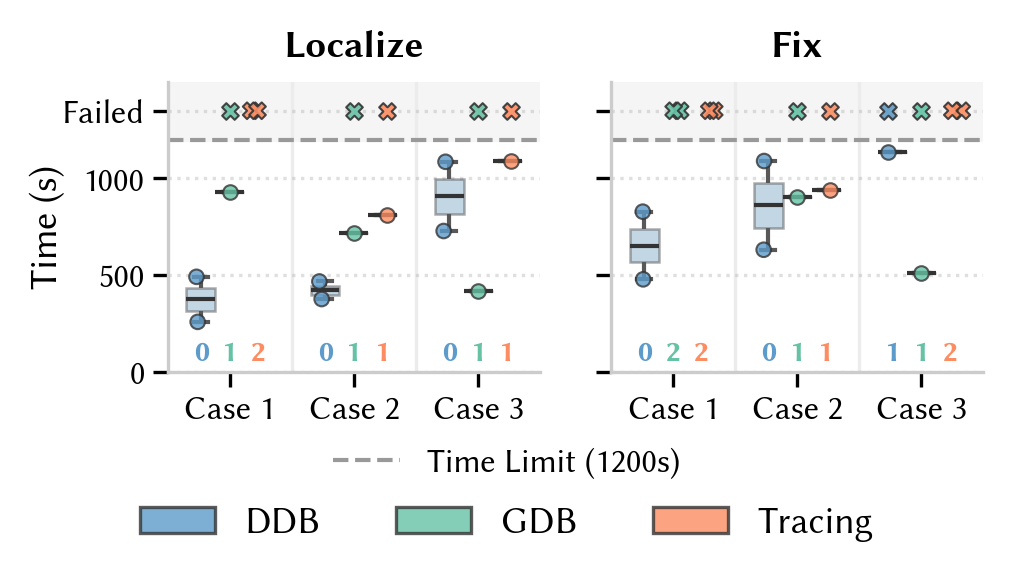

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker 
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Expanded to double-column width (7 inches)
try:
    width = plot_style_apply(template="acm", span=False, usetex=False) + 0.1
except NameError:
    width = 7.0 

# --- 1. STRICTLY YOUR REAL DATA ONLY ---
raw_data = [
    [1, "Case 1", "DDB",     258,    478],
    [1, "Case 2", "Tracing", None,   None],
    [1, "Case 3", "GDB",     420,    510],
    [2, "Case 1", "GDB",     None,   None],
    [2, "Case 2", "DDB",     376,    1090],
    [2, "Case 3", "Tracing", 1090,   None],
    [3, "Case 1", "Tracing", None,   None],
    [3, "Case 2", "GDB",     None,   None],
    [3, "Case 3", "DDB",     728,    None],
    [4, "Case 1", "DDB",     491,    828],
    [4, "Case 2", "Tracing", 812,   940],
    [4, "Case 3", "GDB",     None,    None],
    [5, "Case 1", "GDB",     932,   None],
    [5, "Case 2", "DDB",     467,    631],
    [5, "Case 3", "Tracing", None,   None],
    [6, "Case 1", "Tracing", None,   None],
    [6, "Case 2", "GDB",     720,   906],
    [6, "Case 3", "DDB",     1086,    1136],
]

# --- 2. AUTOMATIC DATA PROCESSING ---
df_wide = pd.DataFrame(raw_data, columns=["User_ID", "Case", "System", "Localize", "Fix"])

df = df_wide.melt(
    id_vars=["User_ID", "Case", "System"], 
    value_vars=["Localize", "Fix"], 
    var_name="Stage", 
    value_name="Time"
)

case_order = ["Case 1", "Case 2", "Case 3"]
system_order = ["DDB", "GDB", "Tracing"]

colors = ["#5D9BCA", "#66C2A5", "#FC8D62"] 
edge_color = "#333333" 

# --- 3. FIGURE SETUP ---
fig, axes = plt.subplots(1, 2, figsize=(width, 1.7), sharey=True)

max_time = df["Time"].max()
if pd.isna(max_time): max_time = 1200 
fail_y = 1350

# PERFECTED DODGE OFFSETS: With width=0.7, the exact centers are 0.233 apart
hue_offsets = [-0.23, 0, 0.23]

# --- Plot A: Time to Localize ONLY ---
loc_data = df[df["Stage"] == "Localize"]

sns.boxplot(
    data=loc_data, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[0], palette=colors, showfliers=False, width=0.7,
    boxprops=dict(alpha=0.4, edgecolor=edge_color, linewidth=0.6),
    medianprops=dict(color=edge_color, linewidth=1.0), zorder=2
)
sns.stripplot(
    data=loc_data, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[0], palette=colors, edgecolor=edge_color, 
    linewidth=0.5, size=3.5, alpha=0.8, jitter=0.1, zorder=4
)

loc_fails = loc_data[loc_data["Time"].isna()].copy()
loc_fails["Time"] = fail_y 
sns.stripplot(
    data=loc_fails, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[0], palette=colors, edgecolor=edge_color, 
    linewidth=0.5, size=4, marker="X", alpha=0.9, jitter=0.3, zorder=5
)

axes[0].set_ylabel("Time (s)", weight="medium", fontsize=9, labelpad=-1)
axes[0].set_title("Localize", fontsize=9, weight="bold")

# Add single-digit annotations for Localize
for i, case in enumerate(case_order):
    for j, system in enumerate(system_order):
        subset = loc_data[(loc_data["Case"] == case) & (loc_data["System"] == system)]
        n_fails = subset["Time"].isna().sum()
        
        x_pos = i + hue_offsets[j]
        axes[0].text(
            x_pos, max_time * 0.02, f"{n_fails}", 
            ha='center', va='bottom', fontsize=7, color=colors[j], 
            weight='bold', zorder=6
        )

# --- Plot B: Time to Fix ONLY ---
fix_data = df[df["Stage"] == "Fix"]

sns.boxplot(
    data=fix_data, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[1], palette=colors, showfliers=False, width=0.7,
    boxprops=dict(alpha=0.4, edgecolor=edge_color, linewidth=0.6),
    medianprops=dict(color=edge_color, linewidth=1.0), zorder=2
)

sns.stripplot(
    data=fix_data, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[1], palette=colors, edgecolor=edge_color, 
    linewidth=0.5, size=3.5, alpha=0.8, jitter=0.1, zorder=4
)

fix_fails = fix_data[fix_data["Time"].isna()].copy()
fix_fails["Time"] = fail_y 
sns.stripplot(
    data=fix_fails, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[1], palette=colors, edgecolor=edge_color, 
    linewidth=0.5, size=4, marker="X", alpha=0.9, jitter=0.3, zorder=5
)

axes[1].set_ylabel("") 
axes[1].set_title("Fix", fontsize=9, weight="bold")

# Add single-digit annotations for Fix
for i, case in enumerate(case_order):
    for j, system in enumerate(system_order):
        subset = fix_data[(fix_data["Case"] == case) & (fix_data["System"] == system)]
        n_fails = subset["Time"].isna().sum()
        
        x_pos = i + hue_offsets[j]
        axes[1].text(
            x_pos, max_time * 0.02, f"{n_fails}", 
            ha='center', va='bottom', fontsize=7, color=colors[j], 
            weight='bold', zorder=6
        )

# --- 4. GLOBAL FORMATTING & CLEAN UP ---
for ax in axes:
    ax.axhspan(1200, 1500, color='#f5f5f5', zorder=0)
    # Note: If you want to use the thicker/darker dashed line from earlier, 
    # change this to: color='#666666', linestyle='--', linewidth=1.5
    ax.axhline(y=1200, color='#999999', linestyle='--', linewidth=1, zorder=1)
    
    ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.set_axisbelow(True) 
    
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=8, pad=2)

    ax.axvline(x=0.5, color='#ECECEC', linestyle='-', linewidth=0.8, zorder=0)
    ax.axvline(x=1.5, color='#ECECEC', linestyle='-', linewidth=0.8, zorder=0)

axes[0].set_ylim(0, 1500)
axes[0].set_yticks([0, 500, 1000, fail_y])

def format_y(val, pos):
    if val == fail_y: return "Failed"
    return f"{int(val)}"
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(format_y))

axes[0].get_legend().remove()
if axes[1].get_legend() is not None: axes[1].get_legend().remove()

# --- TWO-ROW STACKED LEGEND ---

# 1. Top Row: Time Limit
time_limit_handle = Line2D([0], [0], color='#999999', linestyle='--', linewidth=1)
fig.legend([time_limit_handle], ['Time Limit (1200s)'], 
           loc='lower center', bbox_to_anchor=(0.5, -0.02), 
           ncol=1, frameon=False, fontsize=8)

# 2. Bottom Row: Systems (DDB, GDB, Tracing)
system_handles = [
    mpatches.Patch(facecolor=color, edgecolor=edge_color, linewidth=0.8, alpha=0.8) 
    for color in colors
]
fig.legend(system_handles, system_order, 
           loc='lower center', bbox_to_anchor=(0.5, -0.15), 
           ncol=3, frameon=False, fontsize=9)

plt.tight_layout(w_pad=1.5) 

# Increased the bottom margin so both rows fit comfortably without getting cut off
fig.subplots_adjust(bottom=0.25) 

fig.savefig("case_by_case_comparison.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

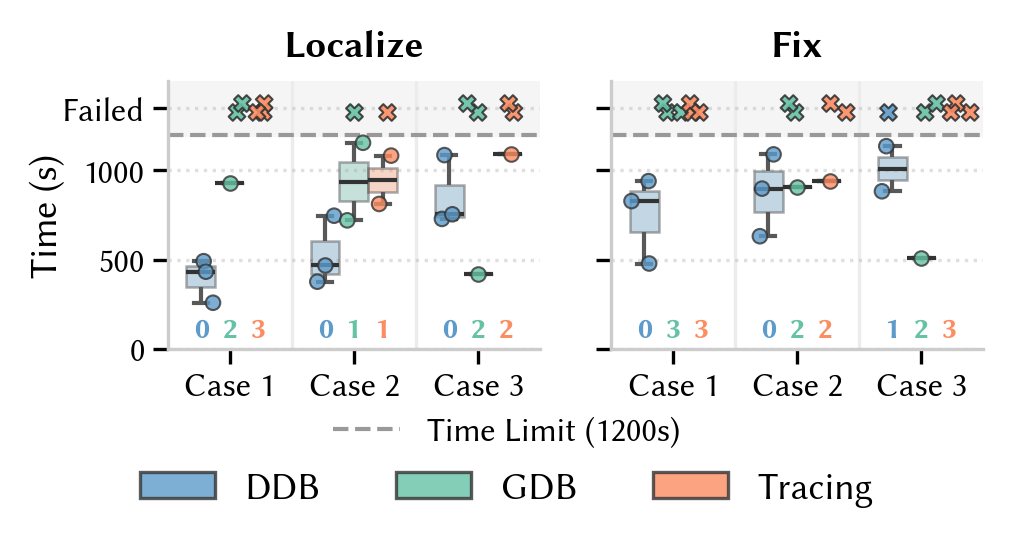

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker 
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Expanded to double-column width (7 inches)
try:
    width = plot_style_apply(template="acm", span=False, usetex=False) + 0.1
except NameError:
    width = 7.0 

# --- 1. STRICTLY YOUR REAL DATA ONLY ---
raw_data = [
    [1, "Case 1", "DDB",     258,    478],
    [1, "Case 2", "Tracing", None,   None],
    [1, "Case 3", "GDB",     420,    510],

    [2, "Case 1", "GDB",     None,   None],
    [2, "Case 2", "DDB",     376,    1090],
    [2, "Case 3", "Tracing", 1090,   None],

    [3, "Case 1", "Tracing", None,   None],
    [3, "Case 2", "GDB",     None,   None],
    [3, "Case 3", "DDB",     728,    None],

    [4, "Case 1", "DDB",     491,    828],
    [4, "Case 2", "Tracing", 812,   940],
    [4, "Case 3", "GDB",     None,    None],

    [5, "Case 1", "GDB",     932,   None],
    [5, "Case 2", "DDB",     467,    631],
    [5, "Case 3", "Tracing", None,   None],

    [6, "Case 1", "Tracing", None,   None],
    [6, "Case 2", "GDB",     720,   906],
    [6, "Case 3", "DDB",     1086,    1136],

    [7, "Case 1", "DDB",     432,    940],
    [7, "Case 2", "Tracing", 1083,   None],
    [7, "Case 3", "GDB",     None,    None],

    [8, "Case 1", "GDB",     None,   None],
    [8, "Case 2", "DDB",     746,    898],
    [8, "Case 3", "Tracing", None,   None],

    [9, "Case 1", "Tracing", None,   None],
    [9, "Case 2", "GDB",     1155,   None],
    [9, "Case 3", "DDB",     754,    883],
]

# --- 2. AUTOMATIC DATA PROCESSING ---
df_wide = pd.DataFrame(raw_data, columns=["User_ID", "Case", "System", "Localize", "Fix"])

df = df_wide.melt(
    id_vars=["User_ID", "Case", "System"], 
    value_vars=["Localize", "Fix"], 
    var_name="Stage", 
    value_name="Time"
)

case_order = ["Case 1", "Case 2", "Case 3"]
system_order = ["DDB", "GDB", "Tracing"]

colors = ["#5D9BCA", "#66C2A5", "#FC8D62"] 
edge_color = "#333333" 

# --- 3. FIGURE SETUP ---
fig, axes = plt.subplots(1, 2, figsize=(width, 1.6), sharey=True)

max_time = df["Time"].max()
if pd.isna(max_time): max_time = 1200 
fail_y = 1350
y_offset = 25 # Distance above and below the center fail line

# PERFECTED DODGE OFFSETS: With width=0.7, the exact centers are 0.233 apart
hue_offsets = [-0.23, 0, 0.23]

# --- Plot A: Time to Localize ONLY ---
loc_data = df[df["Stage"] == "Localize"]

sns.boxplot(
    data=loc_data, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[0], palette=colors, showfliers=False, width=0.7,
    boxprops=dict(alpha=0.4, edgecolor=edge_color, linewidth=0.6),
    medianprops=dict(color=edge_color, linewidth=1.0), zorder=2
)
sns.stripplot(
    data=loc_data, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[0], palette=colors, edgecolor=edge_color, 
    linewidth=0.5, size=3.5, alpha=0.8, jitter=0.4, zorder=4
)

# UPDATED: Localize fails (two rows)
loc_fails = loc_data[loc_data["Time"].isna()].copy()
loc_fails["fail_idx"] = loc_fails.groupby(["Case", "System"]).cumcount()
loc_fails["Time"] = fail_y - y_offset + (loc_fails["fail_idx"] % 2) * (y_offset * 2)

sns.stripplot(
    data=loc_fails, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[0], palette=colors, edgecolor=edge_color, 
    linewidth=0.5, size=4, marker="X", alpha=0.9, jitter=0.4, zorder=5 # Reduced jitter
)

axes[0].set_ylabel("Time (s)", weight="medium", fontsize=9, labelpad=-1)
axes[0].set_title("Localize", fontsize=9, weight="bold")

# Add single-digit annotations for Localize
for i, case in enumerate(case_order):
    for j, system in enumerate(system_order):
        subset = loc_data[(loc_data["Case"] == case) & (loc_data["System"] == system)]
        n_fails = subset["Time"].isna().sum()
        
        x_pos = i + hue_offsets[j]
        axes[0].text(
            x_pos, max_time * 0.02, f"{n_fails}", 
            ha='center', va='bottom', fontsize=7, color=colors[j], 
            weight='bold', zorder=6
        )

# --- Plot B: Time to Fix ONLY ---
fix_data = df[df["Stage"] == "Fix"]

sns.boxplot(
    data=fix_data, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[1], palette=colors, showfliers=False, width=0.7,
    boxprops=dict(alpha=0.4, edgecolor=edge_color, linewidth=0.6),
    medianprops=dict(color=edge_color, linewidth=1.0), zorder=2
)

sns.stripplot(
    data=fix_data, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[1], palette=colors, edgecolor=edge_color, 
    linewidth=0.5, size=3.5, alpha=0.8, jitter=0.4, zorder=4
)

# UPDATED: Fix fails (two rows)
fix_fails = fix_data[fix_data["Time"].isna()].copy()
fix_fails["fail_idx"] = fix_fails.groupby(["Case", "System"]).cumcount()
fix_fails["Time"] = fail_y - y_offset + (fix_fails["fail_idx"] % 2) * (y_offset * 2)

sns.stripplot(
    data=fix_fails, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[1], palette=colors, edgecolor=edge_color, 
    linewidth=0.5, size=4, marker="X", alpha=0.9, jitter=0.4, zorder=5 # Reduced jitter
)

axes[1].set_ylabel("") 
axes[1].set_title("Fix", fontsize=9, weight="bold")

# Add single-digit annotations for Fix
for i, case in enumerate(case_order):
    for j, system in enumerate(system_order):
        subset = fix_data[(fix_data["Case"] == case) & (fix_data["System"] == system)]
        n_fails = subset["Time"].isna().sum()
        
        x_pos = i + hue_offsets[j]
        axes[1].text(
            x_pos, max_time * 0.02, f"{n_fails}", 
            ha='center', va='bottom', fontsize=7, color=colors[j], 
            weight='bold', zorder=6
        )

# --- 4. GLOBAL FORMATTING & CLEAN UP ---
for ax in axes:
    ax.axhspan(1200, 1500, color='#f5f5f5', zorder=0)
    
    ax.axhline(y=1200, color='#999999', linestyle='--', linewidth=1, zorder=1)
    
    ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.set_axisbelow(True) 
    
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=8, pad=2)

    ax.axvline(x=0.5, color='#ECECEC', linestyle='-', linewidth=0.8, zorder=0)
    ax.axvline(x=1.5, color='#ECECEC', linestyle='-', linewidth=0.8, zorder=0)

axes[0].set_ylim(0, 1500)
axes[0].set_yticks([0, 500, 1000, fail_y])

def format_y(val, pos):
    if val == fail_y: return "Failed"
    return f"{int(val)}"
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(format_y))

axes[0].get_legend().remove()
if axes[1].get_legend() is not None: axes[1].get_legend().remove()

# --- TWO-ROW STACKED LEGEND ---

# 1. Top Row: Time Limit
time_limit_handle = Line2D([0], [0], color='#999999', linestyle='--', linewidth=1)
fig.legend([time_limit_handle], ['Time Limit (1200s)'], 
           loc='lower center', bbox_to_anchor=(0.5, -0.02), 
           ncol=1, frameon=False, fontsize=8)

# 2. Bottom Row: Systems (DDB, GDB, Tracing)
system_handles = [
    mpatches.Patch(facecolor=color, edgecolor=edge_color, linewidth=0.8, alpha=0.8) 
    for color in colors
]
fig.legend(system_handles, system_order, 
           loc='lower center', bbox_to_anchor=(0.5, -0.15), 
           ncol=3, frameon=False, fontsize=9)

plt.tight_layout(w_pad=1.5) 

# Increased the bottom margin so both rows fit comfortably without getting cut off
fig.subplots_adjust(bottom=0.25) 

fig.savefig("case_by_case_comparison.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

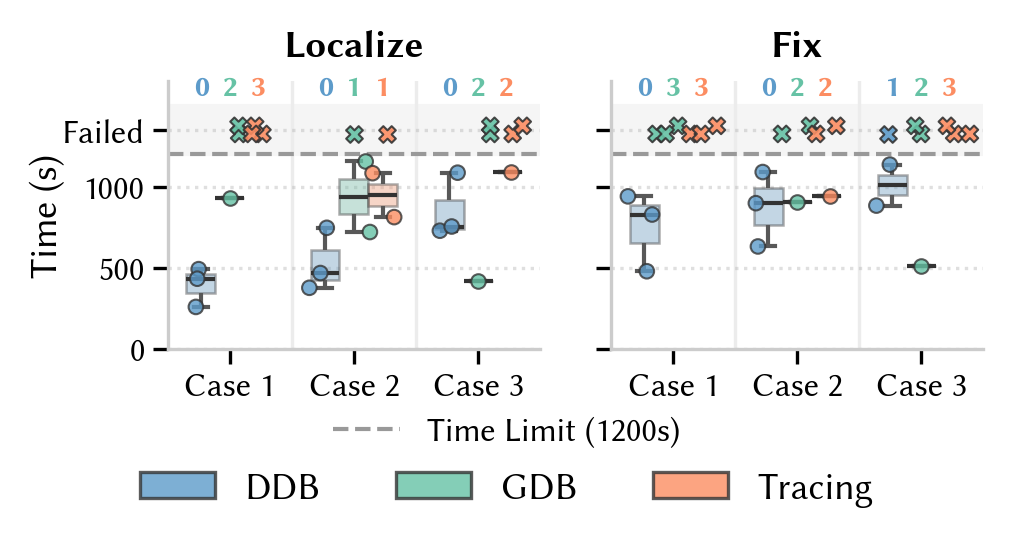

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker 
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Expanded to double-column width (7 inches)
try:
    width = plot_style_apply(template="acm", span=False, usetex=False) + 0.1
except NameError:
    width = 7.0 

# --- 1. STRICTLY YOUR REAL DATA ONLY ---
raw_data = [
    [1, "Case 1", "DDB",     258,    478],
    [1, "Case 2", "Tracing", None,   None],
    [1, "Case 3", "GDB",     420,    510],

    [2, "Case 1", "GDB",     None,   None],
    [2, "Case 2", "DDB",     376,    1090],
    [2, "Case 3", "Tracing", 1090,   None],

    [3, "Case 1", "Tracing", None,   None],
    [3, "Case 2", "GDB",     None,   None],
    [3, "Case 3", "DDB",     728,    None],

    [4, "Case 1", "DDB",     491,    828],
    [4, "Case 2", "Tracing", 812,   940],
    [4, "Case 3", "GDB",     None,    None],

    [5, "Case 1", "GDB",     932,   None],
    [5, "Case 2", "DDB",     467,    631],
    [5, "Case 3", "Tracing", None,   None],

    [6, "Case 1", "Tracing", None,   None],
    [6, "Case 2", "GDB",     720,   906],
    [6, "Case 3", "DDB",     1086,    1136],

    [7, "Case 1", "DDB",     432,    940],
    [7, "Case 2", "Tracing", 1083,   None],
    [7, "Case 3", "GDB",     None,    None],

    [8, "Case 1", "GDB",     None,   None],
    [8, "Case 2", "DDB",     746,    898],
    [8, "Case 3", "Tracing", None,   None],

    [9, "Case 1", "Tracing", None,   None],
    [9, "Case 2", "GDB",     1155,   None],
    [9, "Case 3", "DDB",     754,    883],
]

# --- 2. AUTOMATIC DATA PROCESSING ---
df_wide = pd.DataFrame(raw_data, columns=["User_ID", "Case", "System", "Localize", "Fix"])

df = df_wide.melt(
    id_vars=["User_ID", "Case", "System"], 
    value_vars=["Localize", "Fix"], 
    var_name="Stage", 
    value_name="Time"
)

case_order = ["Case 1", "Case 2", "Case 3"]
system_order = ["DDB", "GDB", "Tracing"]

colors = ["#5D9BCA", "#66C2A5", "#FC8D62"] 
edge_color = "#333333" 

# --- 3. FIGURE SETUP ---
fig, axes = plt.subplots(1, 2, figsize=(width, 1.6), sharey=True)

max_time = df["Time"].max()
if pd.isna(max_time): max_time = 1200 
fail_y = 1350
y_offset = 25 # Distance above and below the center fail line

# PERFECTED DODGE OFFSETS: With width=0.7, the exact centers are 0.233 apart
hue_offsets = [-0.23, 0, 0.23]

# --- Plot A: Time to Localize ONLY ---
loc_data = df[df["Stage"] == "Localize"]

sns.boxplot(
    data=loc_data, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[0], palette=colors, showfliers=False, width=0.7,
    boxprops=dict(alpha=0.4, edgecolor=edge_color, linewidth=0.6),
    medianprops=dict(color=edge_color, linewidth=1.0), zorder=2
)
sns.stripplot(
    data=loc_data, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[0], palette=colors, edgecolor=edge_color, 
    linewidth=0.5, size=3.5, alpha=0.8, jitter=0.4, zorder=4
)

# Localize fails (two rows)
loc_fails = loc_data[loc_data["Time"].isna()].copy()
loc_fails["fail_idx"] = loc_fails.groupby(["Case", "System"]).cumcount()
loc_fails["Time"] = fail_y - y_offset + (loc_fails["fail_idx"] % 2) * (y_offset * 2)

sns.stripplot(
    data=loc_fails, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[0], palette=colors, edgecolor=edge_color, 
    linewidth=0.5, size=4, marker="X", alpha=0.9, jitter=0.4, zorder=5 # Reduced jitter
)

axes[0].set_ylabel("Time (s)", weight="medium", fontsize=9, labelpad=-1)
axes[0].set_title("Localize", fontsize=9, weight="bold")

# UPDATED: Add single-digit annotations for Localize (moved to top gap)
for i, case in enumerate(case_order):
    for j, system in enumerate(system_order):
        subset = loc_data[(loc_data["Case"] == case) & (loc_data["System"] == system)]
        n_fails = subset["Time"].isna().sum()
        
        x_pos = i + hue_offsets[j]
        axes[0].text(
            x_pos, 1520, f"{n_fails}", 
            ha='center', va='bottom', fontsize=7, color=colors[j], 
            weight='bold', zorder=6
        )

# --- Plot B: Time to Fix ONLY ---
fix_data = df[df["Stage"] == "Fix"]

sns.boxplot(
    data=fix_data, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[1], palette=colors, showfliers=False, width=0.7,
    boxprops=dict(alpha=0.4, edgecolor=edge_color, linewidth=0.6),
    medianprops=dict(color=edge_color, linewidth=1.0), zorder=2
)

sns.stripplot(
    data=fix_data, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[1], palette=colors, edgecolor=edge_color, 
    linewidth=0.5, size=3.5, alpha=0.8, jitter=0.4, zorder=4
)

# Fix fails (two rows)
fix_fails = fix_data[fix_data["Time"].isna()].copy()
fix_fails["fail_idx"] = fix_fails.groupby(["Case", "System"]).cumcount()
fix_fails["Time"] = fail_y - y_offset + (fix_fails["fail_idx"] % 2) * (y_offset * 2)

sns.stripplot(
    data=fix_fails, x="Case", y="Time", hue="System",
    order=case_order, hue_order=system_order, dodge=True,
    ax=axes[1], palette=colors, edgecolor=edge_color, 
    linewidth=0.5, size=4, marker="X", alpha=0.9, jitter=0.4, zorder=5 # Reduced jitter
)

axes[1].set_ylabel("") 
axes[1].set_title("Fix", fontsize=9, weight="bold")

# UPDATED: Add single-digit annotations for Fix (moved to top gap)
for i, case in enumerate(case_order):
    for j, system in enumerate(system_order):
        subset = fix_data[(fix_data["Case"] == case) & (fix_data["System"] == system)]
        n_fails = subset["Time"].isna().sum()
        
        x_pos = i + hue_offsets[j]
        axes[1].text(
            x_pos, 1520, f"{n_fails}", 
            ha='center', va='bottom', fontsize=7, color=colors[j], 
            weight='bold', zorder=6
        )

# --- 4. GLOBAL FORMATTING & CLEAN UP ---
for ax in axes:
    # Grey box safely stops at 1500
    ax.axhspan(1200, 1500, color='#f5f5f5', zorder=0)
    
    ax.axhline(y=1200, color='#999999', linestyle='--', linewidth=1, zorder=1)
    
    ax.grid(axis="y", linestyle=":", alpha=0.4, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.set_axisbelow(True) 
    
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=8, pad=2)

    ax.axvline(x=0.5, color='#ECECEC', linestyle='-', linewidth=0.8, zorder=0)
    ax.axvline(x=1.5, color='#ECECEC', linestyle='-', linewidth=0.8, zorder=0)

# UPDATED: Extended Y-axis to 1650 to create white space above grey box
axes[0].set_ylim(0, 1650)
axes[0].set_yticks([0, 500, 1000, fail_y])

def format_y(val, pos):
    if val == fail_y: return "Failed"
    return f"{int(val)}"
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(format_y))

axes[0].get_legend().remove()
if axes[1].get_legend() is not None: axes[1].get_legend().remove()

# --- TWO-ROW STACKED LEGEND ---

# 1. Top Row: Time Limit
time_limit_handle = Line2D([0], [0], color='#999999', linestyle='--', linewidth=1)
fig.legend([time_limit_handle], ['Time Limit (1200s)'], 
           loc='lower center', bbox_to_anchor=(0.5, -0.02), 
           ncol=1, frameon=False, fontsize=8)

# 2. Bottom Row: Systems (DDB, GDB, Tracing)
system_handles = [
    mpatches.Patch(facecolor=color, edgecolor=edge_color, linewidth=0.8, alpha=0.8) 
    for color in colors
]
fig.legend(system_handles, system_order, 
           loc='lower center', bbox_to_anchor=(0.5, -0.15), 
           ncol=3, frameon=False, fontsize=9)

plt.tight_layout(w_pad=1.5) 

# Increased the bottom margin so both rows fit comfortably without getting cut off
fig.subplots_adjust(bottom=0.25) 

fig.savefig("case_by_case_comparison.pdf", bbox_inches="tight", pad_inches=0)
plt.show()